<a href="https://colab.research.google.com/github/VivenG-2007/blackbox-ai-participant-template/blob/main/round-4/GK06_BlackBox_Surrogate_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Reusing saved dataset: /content/drive/MyDrive/black_box_reconstruction/input_dataset.json

DATASET ANALYSIS
Loaded observations: 368
Unique verified inputs: 347
Repeated-input groups: 18

Feature audit:
                     dtype  unique  missing
declared_value     float64      66        0
route_age_days     float64      73        0
shipper_years      float64      55        0
discrepancy_ratio  float64      62        0
shipper_score      float64      74        0
prior_shipments    float64      51        0
recent_seizures    float64      57        0
container_count    float64      51        0
transfers          float64      52        0
port                object       4        0

Feature distributions:
                   count unique  top freq        mean         std    min    25%    50%     75%    max
declared_value     347.0    NaN  NaN  NaN   20.278565   22.724602    0.0    9.8   10.0    25.0  100.0
route_age_days     347.0    NaN  NaN  NaN   38.754862   12.

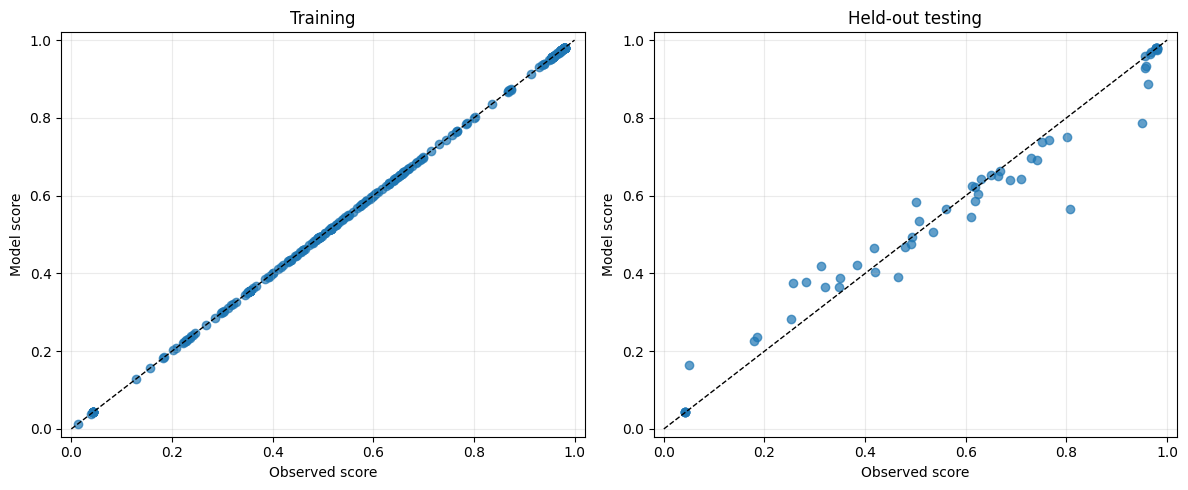


Saved model: /content/drive/MyDrive/black_box_reconstruction/reconstruction_outputs/reconstructed_model.pkl
Cached dataset: /content/drive/MyDrive/black_box_reconstruction/input_dataset.json
Observed decision threshold interval: (0.487, 0.4908]
Operational midpoint: 0.4889
Reconstructed the best-performing tested surrogate supported by the available observations.

Dictionary prediction:
{
  "prediction": {
    "score": 0.679,
    "decision": "APPROVE"
  }
}

JSON string prediction:
{
  "prediction": {
    "score": 0.679,
    "decision": "APPROVE"
  }
}

Batch predictions:
[
  {
    "prediction": {
      "score": 0.679,
      "decision": "APPROVE"
    }
  },
  {
    "prediction": {
      "score": 0.043,
      "decision": "DECLINE"
    }
  },
  {
    "prediction": {
      "score": 0.4794,
      "decision": "DECLINE"
    }
  }
]

Output files:
  expected_training_200.json
  model_comparison.csv
  queries_200_unlabeled.json
  reconstructed_model.pkl
  reconstructed_model_previous.pkl
  re

In [1]:
# ============================================================
# COMPLETE BLACK-BOX RECONSTRUCTION — GOOGLE COLAB
#
# Upload dataset ONCE; subsequent runs reuse the cached file.
# Google Drive cache persists between runtime sessions.
#
# Pipeline:
# Load -> Audit -> Split -> Compare -> Tune -> Blend
# -> Test synthetic augmentation -> Held-out test
# -> Final fit -> Save -> JSON predictions
#
# Synthetic outputs are MODEL ESTIMATES, not true observations.
# ============================================================

import sys
import subprocess
import importlib.util

for package in ["xgboost", "cloudpickle"]:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", package
        ])

import json
import time
import numbers
import warnings
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import cloudpickle
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures,
    SplineTransformer,
    FunctionTransformer,
    Normalizer,
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from xgboost import XGBRegressor

try:
    from google.colab import files, drive, data_table
    data_table.disable_dataframe_formatter()
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42
NEAR_TOL = 0.001
N_SYNTHETIC = 200
PSEUDO_WEIGHT = 0.15

USE_GOOGLE_DRIVE = True

# Change to True only when you want to replace the cached dataset.
UPLOAD_NEW_DATASET = False

# Set True if you want the ZIP automatically downloaded each run.
DOWNLOAD_FILES = False

np.random.seed(SEED)

# Optional pasted dataset. Leave empty to upload/reuse cached JSON.
DATA_JSON = r'''
'''

if IN_COLAB and USE_GOOGLE_DRIVE:
    drive.mount("/content/drive", force_remount=False)
    BASE_DIR = Path(
        "/content/drive/MyDrive/black_box_reconstruction"
    )
else:
    BASE_DIR = Path("black_box_reconstruction")

BASE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE = BASE_DIR / "input_dataset.json"
OUTPUT_DIR = BASE_DIR / "reconstruction_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANGES = {
    "declared_value": (0.0, 100.0),
    "route_age_days": (18.0, 75.0),
    "shipper_years": (0.0, 40.0),
    "discrepancy_ratio": (0.0, 1.0),
    "shipper_score": (300.0, 900.0),
    "prior_shipments": (0.0, 20.0),
    "recent_seizures": (0.0, 5.0),
    "container_count": (0.0, 100.0),
    "transfers": (0.0, 6.0),
}

FEATURES = list(RANGES) + ["port"]
PORTS = ["A", "B", "C", "D"]

REDUCED = [
    field for field in FEATURES
    if field not in [
        "prior_shipments", "container_count", "transfers"
    ]
]

# ============================================================
# 2. VALIDATION HELPERS
# ============================================================

def validate_input(value):
    if isinstance(value, str):
        value = json.loads(value)

    if not isinstance(value, dict):
        raise ValueError("Input must be a dictionary or JSON object.")

    missing = sorted(set(FEATURES) - set(value))
    unknown = sorted(set(value) - set(FEATURES))

    if missing:
        raise ValueError(f"Missing fields: {missing}")
    if unknown:
        raise ValueError(f"Unknown fields: {unknown}")

    result = {}

    for field, (low, high) in RANGES.items():
        number = value[field]

        if (
            isinstance(number, (bool, np.bool_))
            or not isinstance(number, numbers.Real)
        ):
            raise ValueError(f"{field} must be numeric.")

        number = float(number)

        if not np.isfinite(number) or not low <= number <= high:
            raise ValueError(
                f"{field} must be finite and within [{low}, {high}]."
            )

        result[field] = number

    if not isinstance(value["port"], str) or value["port"] not in PORTS:
        raise ValueError(f"port must be one of {PORTS}.")

    result["port"] = value["port"]
    return result


def canonical_keys(frame, fields=FEATURES):
    return np.array([
        json.dumps(
            {field: row[field] for field in fields},
            sort_keys=True,
            separators=(",", ":"),
            allow_nan=False,
        )
        for row in frame.to_dict("records")
    ])


def parse_observations(dataset):
    rows = dataset.get("queries") if isinstance(dataset, dict) else dataset

    if not isinstance(rows, list) or not rows:
        raise ValueError(
            "Expected a nonempty list or an object containing 'queries'."
        )

    normalized = []

    for index, row in enumerate(rows):
        if not isinstance(row, dict):
            raise ValueError(f"Observation {index} must be an object.")

        if (
            row.get("verified") is False
            or row.get("label_source") == "surrogate_estimate"
            or "expected_output" in row
        ):
            raise ValueError(
                f"Observation {index} is synthetic/unverified. "
                "Use only real observed outputs as the source dataset."
            )

        if "input" in row:
            inp = validate_input(row["input"])
            target = row.get("output")
        else:
            absent = sorted(set(FEATURES) - set(row))
            if absent:
                raise ValueError(
                    f"Observation {index}: missing inputs {absent}"
                )
            inp = validate_input({f: row[f] for f in FEATURES})
            target = row

        if not isinstance(target, dict):
            raise ValueError(
                f"Observation {index}: output must contain score/decision."
            )

        score = target.get("score")

        if (
            isinstance(score, bool)
            or not isinstance(score, numbers.Real)
            or not np.isfinite(float(score))
            or not 0 <= float(score) <= 1
        ):
            raise ValueError(f"Observation {index}: invalid score.")

        decision = str(target.get("decision", "")).upper()
        decision = {
            "APPROVED": "APPROVE",
            "DECLINED": "DECLINE",
        }.get(decision, decision)

        if decision not in ["APPROVE", "DECLINE"]:
            raise ValueError(f"Observation {index}: invalid decision.")

        normalized.append({
            "input": inp,
            "output": {
                "score": float(score),
                "decision": decision,
            },
            "round": row.get("round", "unspecified"),
            "query_index": row.get("query_index", index + 1),
            "verified": True,
        })

    return normalized


# ============================================================
# 3. LOAD FILE ONCE AND REUSE CACHE
# Invalid replacement files do not overwrite the valid cache.
# ============================================================

save_cache = False

if DATA_JSON.strip():
    raw_data = json.loads(DATA_JSON)
    save_cache = True
    print("Using pasted JSON.")

elif CACHE_FILE.exists() and not UPLOAD_NEW_DATASET:
    with open(CACHE_FILE, encoding="utf-8") as f:
        raw_data = json.load(f)
    print("Reusing saved dataset:", CACHE_FILE)

elif IN_COLAB:
    print("Upload your VERIFIED observation JSON file.")
    uploaded = files.upload()

    names = [
        name for name in uploaded
        if name.lower().endswith(".json")
    ]

    if len(names) != 1:
        raise ValueError("Upload exactly one JSON file.")

    raw_data = json.loads(
        uploaded[names[0]].decode("utf-8-sig")
    )
    save_cache = True

else:
    with open("dataset.json", encoding="utf-8") as f:
        raw_data = json.load(f)
    save_cache = True

observations = parse_observations(raw_data)

X_all = pd.DataFrame([
    row["input"] for row in observations
])[FEATURES]

y_all = np.array([
    row["output"]["score"] for row in observations
])

labels_all = np.array([
    row["output"]["decision"] for row in observations
])

full_keys = canonical_keys(X_all)

audit = pd.DataFrame({
    "key": full_keys,
    "score": y_all,
    "decision": labels_all,
}).groupby("key").agg(
    count=("score", "size"),
    scores=("score", "nunique"),
    decisions=("decision", "nunique"),
)

conflicts = audit[
    (audit["scores"] > 1) | (audit["decisions"] > 1)
]

if len(conflicts):
    print(conflicts.to_string())
    raise ValueError(
        "Identical inputs have contradictory outputs. "
        "Investigate state/time/stochastic behavior before training."
    )

if save_cache:
    if CACHE_FILE.exists():
        shutil.copy2(
            CACHE_FILE,
            BASE_DIR / "input_dataset_previous.json"
        )

    with open(CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(raw_data, f, indent=2, allow_nan=False)

    print("Dataset cached for future runs:", CACHE_FILE)

unique_mask = ~pd.Series(full_keys).duplicated().to_numpy()

X = X_all.loc[unique_mask].reset_index(drop=True)
y = y_all[unique_mask]
labels = labels_all[unique_mask]

print("\n==============================")
print("DATASET ANALYSIS")
print("==============================")
print("Loaded observations:", len(observations))
print("Unique verified inputs:", len(X))
print("Repeated-input groups:", int((audit["count"] > 1).sum()))

print("\nFeature audit:")
print(pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "unique": X.nunique(),
    "missing": X.isna().sum(),
}).to_string())

print("\nFeature distributions:")
print(X.describe(include="all").T.to_string())

print("\nScore distribution:")
print(pd.Series(y).describe().to_string())

print("\nDecisions:")
print(pd.Series(labels).value_counts().to_string())

print("\nCorrelations with score — association only:")
print(
    X[list(RANGES)].assign(score=y).corr()["score"].to_string()
)

with open(OUTPUT_DIR / "verified_dataset.json", "w") as f:
    json.dump({
        "count": len(observations),
        "queries": observations,
    }, f, indent=2, allow_nan=False)

# Conservative grouping of probes that match on candidate-active fields.
# Full and reduced feature models are both evaluated.
groups = pd.factorize(canonical_keys(X, REDUCED))[0]

if len(np.unique(groups)) < 12:
    raise ValueError("Need at least 12 input groups for this workflow.")


def infer_threshold(scores, decisions):
    rejected = scores[decisions == "DECLINE"]
    approved = scores[decisions == "APPROVE"]

    if len(rejected) == 0 or len(approved) == 0:
        raise ValueError("Both decision classes are required.")

    low = float(rejected.max())
    high = float(approved.min())

    if low >= high:
        raise ValueError(
            "A single score threshold cannot explain these decisions. "
            "A separate decision classifier is required."
        )

    return low, high, (low + high) / 2


# ============================================================
# 4. TRAIN/TEST SPLIT
# ============================================================

dev_index, test_index = next(GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED,
).split(X, y, groups))

Xd = X.iloc[dev_index].reset_index(drop=True)
yd = y[dev_index]
ld = labels[dev_index]
gd = groups[dev_index]

Xt = X.iloc[test_index].reset_index(drop=True)
yt = y[test_index]
lt = labels[test_index]

cv = list(GroupKFold(
    n_splits=min(5, len(np.unique(gd)))
).split(Xd, yd, gd))

for train, val in cv:
    infer_threshold(yd[train], ld[train])

print("\nTraining/development inputs:", len(Xd))
print("Held-out testing inputs:", len(Xt))

# ============================================================
# 5. PREPROCESSING AND CANDIDATES
# ============================================================

def signed_log(values):
    return np.sign(values) * np.log1p(np.abs(values))


def signed_sqrt(values):
    return np.sign(values) * np.sqrt(np.abs(values))


def make_pipeline(model, fields=FEATURES, transform="plain"):
    numeric = [field for field in fields if field != "port"]
    steps = []

    if transform == "log":
        steps.append(("transform", FunctionTransformer(signed_log)))
    elif transform == "sqrt":
        steps.append(("transform", FunctionTransformer(signed_sqrt)))

    steps.append(("scale", StandardScaler()))

    if transform == "poly":
        steps.append((
            "poly", PolynomialFeatures(2, include_bias=False)
        ))
    elif transform == "spline":
        steps.append((
            "spline", SplineTransformer(
                n_knots=5, include_bias=False
            )
        ))
    elif transform == "normalize":
        steps.append(("normalize", Normalizer()))

    transformers = []

    if numeric:
        transformers.append(("numeric", Pipeline(steps), numeric))

    if "port" in fields:
        try:
            encoder = OneHotEncoder(
                handle_unknown="ignore", sparse_output=False
            )
        except TypeError:
            encoder = OneHotEncoder(
                handle_unknown="ignore", sparse=False
            )

        transformers.append(("port", encoder, ["port"]))

    return Pipeline([
        ("prep", ColumnTransformer(
            transformers, remainder="drop"
        )),
        ("model", model),
    ])


class ConditionalScore(RegressorMixin, BaseEstimator):
    """Learn an override gate within each training fold."""

    def __init__(self, base, gate, override=0.043):
        self.base = base
        self.gate = gate
        self.override = override

    def fit(self, X, y):
        y = np.asarray(y)
        flags = np.isclose(
            y, self.override, atol=1e-10, rtol=0
        ).astype(int)

        self.gate_ = clone(self.gate).fit(X, flags)

        keep = np.flatnonzero(flags == 0)
        if len(keep) < 2:
            raise ValueError("Too few non-override observations.")

        self.base_ = clone(self.base).fit(
            X.iloc[keep], y[keep]
        )
        return self

    def predict(self, X):
        normal = self.base_.predict(X)
        return np.where(
            self.gate_.predict(X) == 1,
            self.override,
            normal,
        )


models = {
    "LinearRegression": make_pipeline(LinearRegression()),
    "Ridge": make_pipeline(Ridge(alpha=1.0)),
    "Lasso": make_pipeline(
        Lasso(alpha=0.0001, max_iter=10000)
    ),
    "PolynomialRidge": make_pipeline(
        Ridge(alpha=1.0), transform="poly"
    ),
    "SplineRidge": make_pipeline(
        Ridge(alpha=0.1), transform="spline"
    ),
    "LogRidge": make_pipeline(
        Ridge(alpha=1.0), transform="log"
    ),
    "SqrtRidge": make_pipeline(
        Ridge(alpha=1.0), transform="sqrt"
    ),
    "NormalizedRidge": make_pipeline(
        Ridge(alpha=1.0), transform="normalize"
    ),
    "DecisionTree": make_pipeline(
        DecisionTreeRegressor(max_depth=8, random_state=SEED)
    ),
    "RandomForest": make_pipeline(
        RandomForestRegressor(
            n_estimators=150, n_jobs=2, random_state=SEED
        )
    ),
    "ExtraTrees": make_pipeline(
        ExtraTreesRegressor(
            n_estimators=200, n_jobs=2, random_state=SEED
        )
    ),
    "ExtraTrees_reduced": make_pipeline(
        ExtraTreesRegressor(
            n_estimators=200, n_jobs=2, random_state=SEED
        ),
        REDUCED,
    ),
    "GradientBoosting": make_pipeline(
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.04,
            max_depth=2,
            random_state=SEED,
        )
    ),
    "XGBoost": make_pipeline(
        XGBRegressor(
            n_estimators=250,
            learning_rate=0.04,
            max_depth=3,
            objective="reg:squarederror",
            n_jobs=2,
            random_state=SEED,
        )
    ),
    "XGBoost_reduced": make_pipeline(
        XGBRegressor(
            n_estimators=250,
            learning_rate=0.04,
            max_depth=3,
            objective="reg:squarederror",
            n_jobs=2,
            random_state=SEED,
        ),
        REDUCED,
    ),
    "MLP": make_pipeline(
        MLPRegressor(
            hidden_layer_sizes=(40, 20),
            solver="lbfgs",
            max_iter=1500,
            random_state=SEED,
        )
    ),
}

gate = make_pipeline(
    DecisionTreeClassifier(max_depth=2, random_state=SEED),
    ["port", "route_age_days"],
)

models["Conditional_XGBoost"] = ConditionalScore(
    models["XGBoost_reduced"], gate
)

models["Conditional_ExtraTrees"] = ConditionalScore(
    models["ExtraTrees_reduced"], gate
)

# ============================================================
# 6. VALIDATION METRICS
# ============================================================

def score_metrics(actual, prediction):
    actual = np.asarray(actual, dtype=float)
    prediction = np.clip(
        np.asarray(prediction, dtype=float).reshape(-1), 0, 1
    )

    if len(actual) != len(prediction):
        raise ValueError("Prediction length mismatch.")
    if not np.isfinite(prediction).all():
        raise ValueError("Non-finite predictions.")

    error = np.abs(actual - prediction)

    return {
        "MAE": float(error.mean()),
        "RMSE": float(np.sqrt(mean_squared_error(actual, prediction))),
        "R2": float(r2_score(actual, prediction)),
        "MedianAE": float(np.median(error)),
        "P95Error": float(np.quantile(error, 0.95)),
        "MaxError": float(error.max()),
        "Exact%": float(100 * np.mean(
            np.round(actual, 4) == np.round(prediction, 4)
        )),
        "Near%": float(100 * np.mean(error <= NEAR_TOL)),
    }


def rank(result):
    return (
        -result["Exact%"],
        -result["Near%"],
        result["MaxError"],
        result["MAE"],
        result.get("FoldMAE_SD", 0.0),
    )


def fit_estimator(estimator, frame, target, fit_groups):
    fitted = clone(estimator)
    if isinstance(fitted, RandomizedSearchCV):
        fitted.fit(frame, target, groups=fit_groups)
    else:
        fitted.fit(frame, target)
    return fitted


results = {}
oof_predictions = {}


def evaluate_candidate(name, estimator):
    start = time.time()
    prediction = np.empty(len(Xd))
    errors = []

    for train, val in cv:
        fitted = fit_estimator(
            estimator, Xd.iloc[train], yd[train], gd[train]
        )
        prediction[val] = np.clip(
            fitted.predict(Xd.iloc[val]), 0, 1
        )
        errors.append(
            float(np.mean(np.abs(yd[val] - prediction[val])))
        )

    results[name] = {
        **score_metrics(yd, prediction),
        "FoldMAE_SD": float(np.std(errors)),
        "TrainingSeconds": float(time.time() - start),
    }
    oof_predictions[name] = prediction


for name, estimator in list(models.items()):
    print("Evaluating:", name)
    try:
        evaluate_candidate(name, estimator)
    except Exception as exc:
        print("Skipped:", name, str(exc))

if not results:
    raise RuntimeError("All candidates failed.")

# Nested parameter search.
tunable = [
    name for name in [
        "XGBoost_reduced", "ExtraTrees_reduced", "RandomForest"
    ]
    if name in results
]

if tunable:
    tuning_base = min(tunable, key=lambda name: rank(results[name]))

    if tuning_base.startswith("XGBoost"):
        parameter_space = {
            "model__max_depth": [2, 3, 4],
            "model__n_estimators": [200, 350],
            "model__learning_rate": [0.025, 0.04, 0.08],
            "model__reg_lambda": [0.1, 1.0, 10.0],
        }
    else:
        parameter_space = {
            "model__max_depth": [None, 6, 10],
            "model__min_samples_leaf": [1, 2, 3],
            "model__max_features": [0.7, 1.0],
        }

    tuned_name = tuning_base + "_nested_tuned"
    models[tuned_name] = RandomizedSearchCV(
        clone(models[tuning_base]),
        parameter_space,
        n_iter=4,
        scoring="neg_mean_absolute_error",
        cv=GroupKFold(3),
        n_jobs=1,
        random_state=SEED,
        error_score="raise",
    )

    try:
        print("Nested tuning:", tuned_name)
        evaluate_candidate(tuned_name, models[tuned_name])
    except Exception as exc:
        print("Tuning skipped:", str(exc))

# Fixed-weight blend candidates.
blend_sources = sorted(
    [
        name for name in results
        if not name.endswith("_nested_tuned")
    ],
    key=lambda name: rank(results[name]),
)[:2]

if len(blend_sources) == 2:
    for weight in [0.25, 0.5, 0.75]:
        name = f"Blend_{weight}"
        models[name] = VotingRegressor(
            [
                ("first", clone(models[blend_sources[0]])),
                ("second", clone(models[blend_sources[1]])),
            ],
            weights=[weight, 1 - weight],
        )
        try:
            evaluate_candidate(name, models[name])
        except Exception as exc:
            print("Blend skipped:", str(exc))

order = sorted(results, key=lambda name: rank(results[name]))
best_name = order[0]
teacher_template = models[best_name]

comparison = pd.DataFrame(results).T.loc[order]
comparison.index.name = "Model"
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv")

print("\nTOP FIVE MODELS")
print(comparison.head(5).to_string())
print("\nBest teacher:", best_name)

# ============================================================
# 7. SYNTHETIC INPUT GENERATION
# ============================================================

def generate_inputs(reference, count=200, seed=42, exclude=None):
    rng = np.random.default_rng(seed)
    existing = set(canonical_keys(reference))

    if exclude is not None:
        existing.update(canonical_keys(exclude))

    records = []
    attempts = 0
    ports = sorted(reference["port"].unique())

    while len(records) < count:
        attempts += 1
        if attempts > count * 1000:
            raise RuntimeError("Could not generate enough unique inputs.")

        if rng.random() < 0.75:
            anchor = reference.iloc[
                rng.integers(len(reference))
            ].to_dict()
            record = {}

            for field in RANGES:
                low = float(reference[field].min())
                high = float(reference[field].max())
                delta = rng.normal(0, 0.04 * (high - low))
                record[field] = round(
                    float(np.clip(anchor[field] + delta, low, high)), 4
                )

            record["port"] = anchor["port"]
        else:
            record = {
                field: round(float(rng.uniform(
                    reference[field].min(),
                    reference[field].max(),
                )), 4)
                for field in RANGES
            }
            record["port"] = str(rng.choice(ports))

        record = validate_input(record)
        key = canonical_keys(pd.DataFrame([record]))[0]

        if key not in existing:
            existing.add(key)
            records.append(record)

    return pd.DataFrame(records)[FEATURES]


def fit_student(real_X, real_y, synthetic_X=None, synthetic_y=None):
    student = make_pipeline(
        ExtraTreesRegressor(
            n_estimators=250,
            min_samples_leaf=1,
            max_features=1.0,
            n_jobs=2,
            random_state=SEED,
        )
    )

    if synthetic_X is None:
        student.fit(real_X, real_y)
    else:
        train_X = pd.concat(
            [real_X, synthetic_X], ignore_index=True
        )
        train_y = np.concatenate([real_y, synthetic_y])
        weights = np.concatenate([
            np.ones(len(real_y)),
            np.full(len(synthetic_y), PSEUDO_WEIGHT),
        ])
        student.fit(
            train_X, train_y, model__sample_weight=weights
        )

    return student


# ============================================================
# 8. VALIDATE SYNTHETIC AUGMENTATION
# Uses real development labels, never test outputs.
# ============================================================

pseudo_oof = {
    "Existing_teacher": np.empty(len(Xd)),
    "Student_real_only": np.empty(len(Xd)),
    "Student_plus_estimates": np.empty(len(Xd)),
}

pseudo_fold_metrics = []

for fold, (train, val) in enumerate(cv, start=1):
    print(f"Synthetic validation fold {fold}/{len(cv)}")

    train_X = Xd.iloc[train].reset_index(drop=True)
    train_y = yd[train]
    val_X = Xd.iloc[val]

    teacher = fit_estimator(
        teacher_template, train_X, train_y, gd[train]
    )
    synthetic_X = generate_inputs(
        train_X, N_SYNTHETIC, SEED + fold, exclude=val_X
    )
    synthetic_y = np.clip(
        teacher.predict(synthetic_X), 0, 1
    )

    candidates = {
        "Existing_teacher": teacher,
        "Student_real_only": fit_student(train_X, train_y),
        "Student_plus_estimates": fit_student(
            train_X, train_y, synthetic_X, synthetic_y
        ),
    }

    for name, fitted in candidates.items():
        prediction = np.clip(fitted.predict(val_X), 0, 1)
        pseudo_oof[name][val] = prediction
        pseudo_fold_metrics.append({
            "Fold": fold,
            "Candidate": name,
            **score_metrics(yd[val], prediction),
        })

pseudo_detail = pd.DataFrame(pseudo_fold_metrics)
pseudo_results = {}

for name, prediction in pseudo_oof.items():
    fold_maes = pseudo_detail[
        pseudo_detail["Candidate"] == name
    ]["MAE"].to_numpy()

    pseudo_results[name] = {
        **score_metrics(yd, prediction),
        "FoldMAE_SD": float(np.std(fold_maes)),
    }

pseudo_comparison = pd.DataFrame(pseudo_results).T
print("\nSYNTHETIC AUGMENTATION COMPARISON")
print(pseudo_comparison.to_string())

pseudo_comparison.to_csv(
    OUTPUT_DIR / "synthetic_validation_comparison.csv"
)
pseudo_detail.to_csv(
    OUTPUT_DIR / "synthetic_validation_folds.csv", index=False
)

fold_wins = 0

for fold in range(1, len(cv) + 1):
    table = pseudo_detail[
        pseudo_detail["Fold"] == fold
    ].set_index("Candidate")

    candidate_rank = rank(table.loc["Student_plus_estimates"])

    if (
        candidate_rank < rank(table.loc["Existing_teacher"])
        and candidate_rank < rank(table.loc["Student_real_only"])
    ):
        fold_wins += 1

accept_synthetic_update = (
    rank(pseudo_results["Student_plus_estimates"])
    < rank(pseudo_results["Existing_teacher"])
    and rank(pseudo_results["Student_plus_estimates"])
    < rank(pseudo_results["Student_real_only"])
    and fold_wins > len(cv) / 2
)

selected_strategy = (
    "Student_plus_estimates"
    if accept_synthetic_update
    else "Existing_teacher"
)

selected_oof = pseudo_oof[selected_strategy]

print("\nSelected strategy:", selected_strategy)
print("Synthetic update accepted:", accept_synthetic_update)

# ============================================================
# 9. RESIDUAL ANALYSIS
# ============================================================

residual = yd - selected_oof
residual_tables = []

for field in FEATURES:
    bins = (
        Xd[field]
        if field == "port" or Xd[field].nunique() <= 1
        else pd.qcut(Xd[field], 4, duplicates="drop")
    )

    table = pd.DataFrame({
        "bin": bins,
        "residual": residual,
        "error": np.abs(residual),
    }).groupby("bin", observed=True).agg(
        count=("error", "size"),
        mean_residual=("residual", "mean"),
        MAE=("error", "mean"),
        MaxError=("error", "max"),
    ).reset_index()

    table["bin"] = table["bin"].astype(str)
    table["feature"] = field
    residual_tables.append(table)

pd.concat(residual_tables, ignore_index=True).to_csv(
    OUTPUT_DIR / "residual_analysis.csv", index=False
)

# ============================================================
# 10. TRAINING AND HELD-OUT TEST SCORES
# Strategy fixed before test evaluation.
# ============================================================

development_teacher = fit_estimator(
    teacher_template, Xd, yd, gd
)

if accept_synthetic_update:
    dev_synthetic_X = generate_inputs(
        Xd, N_SYNTHETIC, SEED + 300
    )
    dev_synthetic_y = np.clip(
        development_teacher.predict(dev_synthetic_X), 0, 1
    )
    test_model = fit_student(
        Xd, yd, dev_synthetic_X, dev_synthetic_y
    )
else:
    test_model = development_teacher

training_scores = np.clip(test_model.predict(Xd), 0, 1)
test_scores = np.clip(test_model.predict(Xt), 0, 1)

_, _, threshold_dev = infer_threshold(yd, ld)

training_decisions = np.where(
    training_scores >= threshold_dev, "APPROVE", "DECLINE"
)
test_decisions = np.where(
    test_scores >= threshold_dev, "APPROVE", "DECLINE"
)

training_metrics = score_metrics(yd, training_scores)
heldout_metrics = score_metrics(yt, test_scores)

training_testing_summary = pd.DataFrame({
    "Training": training_metrics,
    "Held-out testing": heldout_metrics,
})

training_testing_summary.loc["Decision accuracy %"] = [
    100 * accuracy_score(ld, training_decisions),
    100 * accuracy_score(lt, test_decisions),
]

training_testing_summary.to_csv(
    OUTPUT_DIR / "training_testing_scores.csv"
)

decision_metrics = {
    "Accuracy": float(accuracy_score(lt, test_decisions)),
    "Precision": float(precision_score(
        lt, test_decisions, pos_label="APPROVE", zero_division=0
    )),
    "Recall": float(recall_score(
        lt, test_decisions, pos_label="APPROVE", zero_division=0
    )),
    "F1": float(f1_score(
        lt, test_decisions, pos_label="APPROVE", zero_division=0
    )),
}

decision_oof = np.empty(len(Xd), dtype=object)

for train, val in cv:
    _, _, threshold = infer_threshold(yd[train], ld[train])
    decision_oof[val] = np.where(
        selected_oof[val] >= threshold, "APPROVE", "DECLINE"
    )

print("\n==============================")
print("TRAINING AND TESTING SCORES")
print("==============================")
print(training_testing_summary.round(6).to_string())

print("\nDevelopment cross-validation:")
print(pd.Series(pseudo_results[selected_strategy]).to_string())
print("CV decision accuracy:", accuracy_score(ld, decision_oof))

print("\nHeld-out decision metrics:")
print(pd.Series(decision_metrics).to_string())

print(
    "\nTraining scores measure fit to known inputs. "
    "Held-out testing measures reproduction on reserved input groups."
)
print(
    "Exact%: four-decimal score agreement. "
    f"Near%: absolute error <= {NEAR_TOL}."
)
print(
    "No log loss is reported because threshold decisions "
    "are not calibrated class probabilities."
)

# Quick score visualization.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, actual, predicted, title in [
    (axes[0], yd, training_scores, "Training"),
    (axes[1], yt, test_scores, "Held-out testing"),
]:
    ax.scatter(actual, predicted, alpha=0.7)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set(
        xlabel="Observed score",
        ylabel="Model score",
        title=title,
        xlim=(-0.02, 1.02),
        ylim=(-0.02, 1.02),
    )
    ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "training_testing_plot.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# 11. FINAL FIT AND 200 ESTIMATED RECORDS
# ============================================================

final_teacher = fit_estimator(
    teacher_template, X, y, groups
)

synthetic_X = generate_inputs(X, N_SYNTHETIC, SEED + 500)
synthetic_y = np.clip(final_teacher.predict(synthetic_X), 0, 1)

threshold_low, threshold_high, final_threshold = infer_threshold(
    y, labels
)

estimated_records = []

for index, (record, score) in enumerate(
    zip(synthetic_X.to_dict("records"), synthetic_y),
    start=1,
):
    estimated_records.append({
        "query_index": index,
        "input": record,
        "expected_output": {
            "score": round(float(score), 4),
            "decision": (
                "APPROVE" if score >= final_threshold else "DECLINE"
            ),
        },
        "label_source": "surrogate_estimate",
        "verified": False,
        "training_weight": PSEUDO_WEIGHT,
    })

with open(OUTPUT_DIR / "expected_training_200.json", "w") as f:
    json.dump({
        "count": N_SYNTHETIC,
        "teacher": best_name,
        "warning": "Estimated labels, not hidden-system observations.",
        "queries": estimated_records,
    }, f, indent=2, allow_nan=False)

with open(OUTPUT_DIR / "queries_200_unlabeled.json", "w") as f:
    json.dump({
        "count": N_SYNTHETIC,
        "queries": [
            {"query_index": row["query_index"], **row["input"]}
            for row in estimated_records
        ],
    }, f, indent=2, allow_nan=False)

final_estimator = (
    fit_student(X, y, synthetic_X, synthetic_y)
    if accept_synthetic_update
    else final_teacher
)

# ============================================================
# 12. SAVED MODEL AND JSON PREDICTION API
# ============================================================

class JSONModel:
    def __init__(self, model, threshold, threshold_bounds, model_name):
        self.model = model
        self.threshold = float(threshold)
        self.threshold_bounds = tuple(threshold_bounds)
        self.model_name = model_name

    def predict_batch_json(self, inputs):
        if isinstance(inputs, str):
            inputs = json.loads(inputs)

        if not isinstance(inputs, list):
            raise ValueError("Batch must be a list of input dictionaries.")

        if not inputs:
            return []

        records = []
        for index, value in enumerate(inputs):
            try:
                records.append(validate_input(value))
            except (ValueError, TypeError) as exc:
                raise ValueError(
                    f"Batch index {index}: {exc}"
                ) from exc

        frame = pd.DataFrame(records)[FEATURES]
        scores = np.asarray(
            self.model.predict(frame), dtype=float
        ).reshape(-1)

        if len(scores) != len(records) or not np.isfinite(scores).all():
            raise RuntimeError("Invalid model predictions.")

        scores = np.clip(scores, 0, 1)

        low, high = self.threshold_bounds
        if np.any((scores > low) & (scores < high)):
            warnings.warn(
                "A predicted score is inside the unresolved decision "
                "threshold interval. The midpoint determines its decision."
            )

        return [
            {
                "prediction": {
                    "score": round(float(score), 4),
                    "decision": (
                        "APPROVE"
                        if score >= self.threshold
                        else "DECLINE"
                    ),
                }
            }
            for score in scores
        ]

    def predict_json(self, input_json):
        return self.predict_batch_json([input_json])[0]


final_pipeline = JSONModel(
    final_estimator,
    final_threshold,
    (threshold_low, threshold_high),
    (
        "Synthetic_augmented_ExtraTrees"
        if accept_synthetic_update
        else best_name
    ),
)

teacher_pipeline = JSONModel(
    final_teacher,
    final_threshold,
    (threshold_low, threshold_high),
    best_name,
)


def predict_json(input_json):
    return final_pipeline.predict_json(input_json)


def predict_batch_json(inputs):
    return final_pipeline.predict_batch_json(inputs)


model_path = OUTPUT_DIR / "reconstructed_model.pkl"

if model_path.exists():
    shutil.copy2(
        model_path,
        OUTPUT_DIR / "reconstructed_model_previous.pkl"
    )

# Trusted files only: loading pickle data can execute code.
joblib.dump(cloudpickle.dumps(final_pipeline), model_path)
joblib.dump(
    cloudpickle.dumps(teacher_pipeline),
    OUTPUT_DIR / "teacher_model.pkl",
)

report = {
    "loaded_verified_observations": len(observations),
    "unique_verified_inputs": len(X),
    "training_partition_inputs": len(Xd),
    "testing_partition_inputs": len(Xt),
    "best_teacher": best_name,
    "selected_strategy": selected_strategy,
    "synthetic_update_accepted": bool(accept_synthetic_update),
    "synthetic_records_generated": N_SYNTHETIC,
    "synthetic_records_used": (
        N_SYNTHETIC if accept_synthetic_update else 0
    ),
    "synthetic_training_weight": PSEUDO_WEIGHT,
    "synthetic_validation_fold_wins": fold_wins,
    "development_validation": pseudo_results[selected_strategy],
    "training_metrics": training_metrics,
    "held_out_test": heldout_metrics,
    "held_out_decision_metrics": decision_metrics,
    "decision_threshold_estimate": final_threshold,
    "threshold_lower_exclusive": threshold_low,
    "threshold_upper_inclusive": threshold_high,
    "near_tolerance": NEAR_TOL,
    "warning": (
        "The 200 generated labels are estimates. "
        "Final model is refitted on all verified observations; "
        "held-out metrics describe the pre-refit evaluation model."
    ),
}

with open(OUTPUT_DIR / "reconstruction_report.json", "w") as f:
    json.dump(report, f, indent=2, allow_nan=False)

print("\nSaved model:", model_path)
print("Cached dataset:", CACHE_FILE)
print(
    f"Observed decision threshold interval: "
    f"({threshold_low}, {threshold_high}]"
)
print("Operational midpoint:", final_threshold)
print(
    "Reconstructed the best-performing tested surrogate "
    "supported by the available observations."
)

# ============================================================
# 13. PREDICTION EXAMPLES
# ============================================================

new_input = {
    "declared_value": 35.0,
    "route_age_days": 42.0,
    "shipper_years": 15.0,
    "discrepancy_ratio": 0.65,
    "shipper_score": 720.0,
    "prior_shipments": 8.0,
    "recent_seizures": 3.0,
    "container_count": 40.0,
    "transfers": 2.0,
    "port": "B",
}

print("\nDictionary prediction:")
print(json.dumps(predict_json(new_input), indent=2))

print("\nJSON string prediction:")
print(json.dumps(predict_json(json.dumps(new_input)), indent=2))

print("\nBatch predictions:")
print(json.dumps(predict_batch_json([
    new_input,
    {**new_input, "route_age_days": 33.5, "port": "C"},
    {**new_input, "declared_value": 90.0, "route_age_days": 70.0},
]), indent=2))

# ============================================================
# 14. OPTIONAL DOWNLOAD
# All outputs already saved in Google Drive when enabled.
# ============================================================

print("\nOutput files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" ", path.name)

if DOWNLOAD_FILES:
    zip_path = shutil.make_archive(
        "/content/reconstruction_bundle" if IN_COLAB
        else "reconstruction_bundle",
        "zip",
        root_dir=str(OUTPUT_DIR),
    )
    if IN_COLAB:
        files.download(zip_path)
    else:
        print("ZIP:", zip_path)

# ============================================================
# RELOAD SAVED MODEL WITHOUT RETRAINING
# Only load trusted files.
#
# loaded_model = cloudpickle.loads(joblib.load(
#     "/content/drive/MyDrive/black_box_reconstruction/"
#     "reconstruction_outputs/reconstructed_model.pkl"
# ))
# print(loaded_model.predict_json(new_input))
#
# To replace the dataset:
# UPLOAD_NEW_DATASET = True
# Run once, then change back to False.
#
# This notebook reuses the dataset but RETRAINS on each full run.
# ============================================================

In [2]:
# ============================================================
# COMPLETE COLAB UI — NAVY / VIOLET / CYAN
# No observation chart or observation table.
# Run after the model training cell.
# ============================================================

import json
import uuid
import warnings
import numbers
import numpy as np

from IPython.display import display, HTML, JSON
from google.colab import output

# ------------------------------------------------------------
# 1. Check trained model
# ------------------------------------------------------------

if (
    "final_pipeline" not in globals()
    or not callable(getattr(final_pipeline, "predict_json", None))
):
    raise RuntimeError(
        "The trained model is not ready. Run the training cell first "
        "and wait until it prints 'Saved reconstructed_model.pkl'."
    )

# ------------------------------------------------------------
# 2. Input specification
# ------------------------------------------------------------

UI_RANGES = {
    "container_count": (0.0, 100.0),
    "declared_value": (0.0, 100.0),
    "discrepancy_ratio": (0.0, 1.0),
    "prior_shipments": (0.0, 20.0),
    "recent_seizures": (0.0, 5.0),
    "route_age_days": (18.0, 75.0),
    "shipper_score": (300.0, 900.0),
    "shipper_years": (0.0, 40.0),
    "transfers": (0.0, 6.0)
}

UI_DEFAULTS = {
    "container_count": 50.0,
    "declared_value": 10.0,
    "discrepancy_ratio": 0.5,
    "port": "A",
    "prior_shipments": 10.0,
    "recent_seizures": 2.5,
    "route_age_days": 46.5,
    "shipper_score": 600.0,
    "shipper_years": 20.0,
    "transfers": 3.0
}

UI_FIELD_ORDER = [
    "container_count", "declared_value",
    "discrepancy_ratio", "port",
    "prior_shipments", "recent_seizures",
    "route_age_days", "shipper_score",
    "shipper_years", "transfers"
]

ui_model = final_pipeline


def validate_ui_manifest(value):
    if not isinstance(value, dict):
        raise ValueError("Input must be a JSON object.")

    required = set(UI_DEFAULTS)
    missing = required - set(value)
    unknown = set(value) - required

    if missing:
        raise ValueError(f"Missing fields: {sorted(missing)}")

    if unknown:
        raise ValueError(f"Unknown fields: {sorted(unknown)}")

    validated = {}

    for field, (low, high) in UI_RANGES.items():
        number = value[field]

        if isinstance(number, (bool, np.bool_)) or not isinstance(
            number, numbers.Real
        ):
            raise ValueError(f"{field} must be a number.")

        number = float(number)

        if not np.isfinite(number):
            raise ValueError(f"{field} must be finite.")

        if not low <= number <= high:
            raise ValueError(
                f"{field} must be between {low} and {high}; "
                f"received {number}."
            )

        validated[field] = number

    port = value["port"]

    if not isinstance(port, str) or port not in ["A", "B", "C", "D"]:
        raise ValueError("port must be A, B, C, or D.")

    validated["port"] = port
    return validated


def ui_prediction_callback(value):
    try:
        validated = validate_ui_manifest(value)

        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter("always")
            result = ui_model.predict_json(validated)

        if not isinstance(result, dict):
            raise RuntimeError("Model output must be a dictionary.")

        if "prediction" in result:
            result = result["prediction"]

        score = float(result["score"])
        decision = str(result["decision"]).strip().lower()

        decision = {
            "approve": "approved",
            "decline": "declined"
        }.get(decision, decision)

        if not np.isfinite(score) or not 0 <= score <= 1:
            raise RuntimeError("Model returned an invalid score.")

        if decision not in ["approved", "declined"]:
            raise RuntimeError("Model returned an invalid decision.")

        return JSON({
            "ok": True,
            "prediction": {
                "score": round(score, 4),
                "decision": decision
            },
            "warnings": list(dict.fromkeys(
                str(item.message) for item in captured
            ))
        })

    except Exception as exc:
        return JSON({
            "ok": False,
            "error": str(exc)
        })


callback_name = "manifest_ui.predict_" + uuid.uuid4().hex
output.register_callback(callback_name, ui_prediction_callback)

config_json = json.dumps({
    "callback": callback_name,
    "ranges": UI_RANGES,
    "defaults": UI_DEFAULTS,
    "order": UI_FIELD_ORDER
}, allow_nan=False).replace("<", "\\u003c")

# ------------------------------------------------------------
# 3. Complete HTML interface
# ------------------------------------------------------------

ui_html = r"""
<div id="manifest-ui">
<style>
#manifest-ui {
    --bg: #0b1020;
    --panel: #141b32;
    --card: #1b2542;
    --border: #354363;
    --text: #f0f4ff;
    --muted: #a7b5d1;
    --violet: #a78bfa;
    --cyan: #67e8f9;
    --green: #2dd4bf;
    --red: #fb7185;

    background: linear-gradient(135deg, #0b1020, #16132e);
    color: var(--text);
    border: 1px solid var(--border);
    border-radius: 16px;
    padding: 24px;
    font-family: Arial, sans-serif;
}

#manifest-ui * { box-sizing: border-box; }

#manifest-ui .layout {
    display: grid;
    grid-template-columns: minmax(0, 3fr) minmax(240px, 1fr);
    gap: 20px;
}

#manifest-ui .panel {
    background: linear-gradient(145deg, #17213b, #11182d);
    border: 1px solid var(--border);
    border-radius: 13px;
    padding: 22px;
}

#manifest-ui .header {
    display: flex;
    justify-content: space-between;
    align-items: center;
    gap: 12px;
    margin-bottom: 20px;
}

#manifest-ui h2 {
    margin: 0;
    font-size: 23px;
}

#manifest-ui .tag {
    color: var(--cyan);
    border: 1px solid #397d91;
    border-radius: 20px;
    padding: 5px 10px;
    font: 11px monospace;
}

#manifest-ui .console {
    display: grid;
    grid-template-columns: minmax(0, 1.35fr) minmax(250px, 1fr);
    gap: 20px;
}

#manifest-ui .fields {
    display: grid;
    grid-template-columns: repeat(2, minmax(0, 1fr));
    gap: 12px;
}

#manifest-ui .field {
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 10px;
    padding: 14px;
    min-width: 0;
}

#manifest-ui .field-label {
    font: bold 12px monospace;
    margin-bottom: 12px;
    overflow-wrap: anywhere;
}

#manifest-ui .dot {
    display: inline-block;
    width: 7px;
    height: 7px;
    margin-right: 7px;
    border-radius: 50%;
    background: var(--violet);
    box-shadow: 0 0 0 3px #a78bfa20;
}

#manifest-ui .input-row {
    display: flex;
    align-items: center;
    gap: 10px;
}

#manifest-ui input[type=range] {
    flex: 1;
    width: 100%;
    min-width: 30px;
    accent-color: var(--violet);
    cursor: pointer;
}

#manifest-ui input[type=number],
#manifest-ui select,
#manifest-ui textarea {
    background: #10182d;
    color: var(--text);
    border: 1px solid #465577;
    border-radius: 6px;
    padding: 9px;
    font: 13px monospace;
}

#manifest-ui input[type=number] { width: 88px; }
#manifest-ui select { width: 100%; }

#manifest-ui input:focus,
#manifest-ui select:focus,
#manifest-ui textarea:focus {
    outline: 2px solid var(--violet);
    outline-offset: 2px;
}

#manifest-ui .limits {
    display: flex;
    justify-content: space-between;
    color: var(--muted);
    font: 10px monospace;
    margin-top: 9px;
}

#manifest-ui .buttons {
    display: flex;
    gap: 9px;
    flex-wrap: wrap;
    margin-top: 16px;
}

#manifest-ui button {
    background: #22304e;
    color: var(--text);
    border: 1px solid #465577;
    border-radius: 7px;
    padding: 11px 14px;
    font: bold 11px monospace;
    cursor: pointer;
    transition: background 0.15s;
}

#manifest-ui button:hover:not(:disabled) {
    background: #344566;
}

#manifest-ui button.primary {
    background: var(--violet);
    border-color: var(--violet);
    color: #17102d;
}

#manifest-ui button.primary:hover:not(:disabled) {
    background: #c4b5fd;
}

#manifest-ui button.outline {
    color: var(--cyan);
    border-color: #397d91;
}

#manifest-ui button:disabled {
    opacity: 0.45;
    cursor: not-allowed;
}

#manifest-ui .card {
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 11px;
    padding: 20px;
    margin-bottom: 15px;
}

#manifest-ui .small {
    font: 12px monospace;
    line-height: 1.8;
    color: var(--muted);
}

#manifest-ui .score {
    font: bold 46px monospace;
    margin: 22px 0 14px;
    overflow-wrap: anywhere;
}

#manifest-ui .badge {
    border: 1px solid #637393;
    border-radius: 22px;
    padding: 7px 11px;
    font: bold 11px monospace;
}

#manifest-ui .approved {
    color: var(--green);
    border-color: #2dd4bf70;
    background: #2dd4bf15;
}

#manifest-ui .declined {
    color: var(--red);
    border-color: #fb718570;
    background: #fb718515;
}

#manifest-ui .system-title {
    color: var(--cyan);
    font: bold 35px monospace;
    margin: 10px 0;
}

#manifest-ui .description {
    font-size: 14px;
    line-height: 1.9;
}

#manifest-ui hr {
    border: 0;
    border-top: 1px solid var(--border);
    margin: 18px 0;
}

#manifest-ui textarea {
    width: 100%;
    min-height: 250px;
    resize: vertical;
    line-height: 1.6;
}

#manifest-ui pre {
    background: #10182d;
    color: var(--text);
    border: 1px solid #465577;
    border-radius: 7px;
    padding: 14px;
    white-space: pre-wrap;
    overflow-wrap: anywhere;
    font: 12px monospace;
    line-height: 1.7;
}

#manifest-ui .error {
    color: var(--red);
    font: 12px monospace;
    white-space: pre-wrap;
    line-height: 1.7;
}

#manifest-ui .warning {
    color: #c4b5fd;
    white-space: pre-wrap;
}

#manifest-ui .hidden { display: none; }

#manifest-ui .schema-row {
    display: flex;
    justify-content: space-between;
    gap: 12px;
    padding: 9px 0;
    border-bottom: 1px solid var(--border);
    font: 11px monospace;
}

#manifest-ui .schema-row span:first-child {
    overflow-wrap: anywhere;
}

#manifest-ui .schema-row span:last-child {
    color: var(--cyan);
    text-align: right;
    white-space: nowrap;
}

@media (max-width: 1100px) {
    #manifest-ui .layout { grid-template-columns: 1fr; }
}

@media (max-width: 700px) {
    #manifest-ui { padding: 12px; }
    #manifest-ui .panel { padding: 15px; }
    #manifest-ui .console { grid-template-columns: 1fr; }
}

@media (max-width: 430px) {
    #manifest-ui .fields { grid-template-columns: 1fr; }
}
</style>

<div class="layout">

    <section class="panel">
        <div class="header">
            <h2>Query console</h2>
            <span class="tag">MODEL READY</span>
        </div>

        <div class="console">

            <div>
                <div id="fields" class="fields"></div>

                <div class="buttons">
                    <button id="send" class="primary">SEND QUERY</button>
                    <button id="random" class="outline">RANDOMISE</button>
                    <button id="reset">RESET</button>
                </div>

                <div class="buttons">
                    <button id="copy-input">COPY INPUT JSON</button>
                    <button id="toggle-input">JSON INPUT</button>
                </div>

                <div id="json-input-panel" class="hidden"
                     style="margin-top:18px">
                    <div class="small">
                        Paste one input object with all 10 fields.
                    </div>
                    <textarea id="json-input"
                              aria-label="Input JSON"></textarea>
                    <div class="buttons">
                        <button id="load-json" class="outline">
                            LOAD JSON INTO FORM
                        </button>
                    </div>
                </div>

                <p id="status" class="small" aria-live="polite">
                    Ready. Enter inputs and send a query.
                </p>
                <div id="errors" class="error" aria-live="polite"></div>
            </div>

            <div>
                <div class="card">
                    <div class="header" style="margin-bottom:0">
                        <span class="small">PREDICTION RESULT</span>
                        <span id="decision" class="badge">WAITING</span>
                    </div>

                    <div id="score" class="score">—</div>
                    <div class="small">Score out of 1</div>

                    <hr>

                    <div class="small">
                        Δ from previous:
                        <strong id="delta">—</strong>
                    </div>
                    <div class="small">
                        Prediction:
                        <strong id="query-number">#0</strong>
                    </div>

                    <hr>

                    <div class="small">Changed input fields:</div>
                    <div id="changes" class="small"
                         style="color:var(--violet)">
                        No previous prediction.
                    </div>

                    <div id="warnings" class="small warning"
                         style="margin-top:12px"></div>
                </div>

                <button id="toggle-output" class="outline">
                    SHOW JSON OUTPUT
                </button>

                <div id="json-output-panel" class="card hidden"
                     style="margin-top:15px">
                    <b>Prediction JSON</b>
                    <pre id="json-output">No prediction yet.</pre>

                    <div class="buttons">
                        <button id="copy-output" disabled>COPY JSON</button>
                        <button id="download" disabled>DOWNLOAD JSON</button>
                    </div>
                </div>
            </div>

        </div>
    </section>

    <aside class="panel">
        <div class="small">YOUR SURROGATE SYSTEM</div>
        <div class="system-title">GK-06</div>
        <div class="small">Score & decision predictor</div>

        <p class="description">
            Enter a shipment manifest to estimate its score and decision.
            All 10 fields are required.
        </p>

        <p class="small">
            Output: score between 0 and 1, with
            <span style="color:var(--green)">approved</span> or
            <span style="color:var(--red)">declined</span>.
        </p>

        <p class="small">
            Fractional numbers are accepted within the specified ranges.
            Randomise only changes the form; it does not submit a query.
        </p>

        <hr>

        <details>
            <summary class="small" style="cursor:pointer">
                INPUT RANGES
            </summary>
            <div id="schema" style="margin-top:8px"></div>
        </details>

        <hr>

        <p class="small">
            Predictions come from your trained surrogate, not the original
            hidden system. The score is not necessarily a calibrated
            probability. Unseen input combinations may be less accurate.
        </p>
    </aside>

</div>

<script>
(() => {
    const cfg = __CONFIG__;
    const root = document.getElementById("manifest-ui");
    const get = id => root.querySelector("#" + id);

    const controls = {};
    const sliders = {};

    let previousInput = null;
    let previousScore = null;
    let lastResult = null;
    let predictionCount = 0;

    function showError(message) {
        get("errors").textContent = message || "";
    }

    function validateObject(value) {
        if (!value || typeof value !== "object" || Array.isArray(value)) {
            throw new Error("JSON input must be one object.");
        }

        const missing = cfg.order.filter(field => !(field in value));
        const unknown = Object.keys(value).filter(
            field => !cfg.order.includes(field)
        );

        if (missing.length) {
            throw new Error("Missing fields: " + missing.join(", "));
        }

        if (unknown.length) {
            throw new Error("Unknown fields: " + unknown.join(", "));
        }

        for (const field of cfg.order) {
            if (field === "port") {
                if (!["A", "B", "C", "D"].includes(value[field])) {
                    throw new Error("port must be A, B, C, or D.");
                }
            } else {
                const number = value[field];
                const [low, high] = cfg.ranges[field];

                if (
                    typeof number !== "number" ||
                    !Number.isFinite(number) ||
                    number < low ||
                    number > high
                ) {
                    throw new Error(
                        `${field} must be a number within [${low}, ${high}].`
                    );
                }
            }
        }

        return value;
    }

    function readForm() {
        const value = {};

        for (const field of cfg.order) {
            if (field === "port") {
                value[field] = controls[field].value;
            } else {
                const raw = controls[field].value.trim();

                if (raw === "") {
                    throw new Error(field + " is required.");
                }

                value[field] = Number(raw);
            }
        }

        return validateObject(value);
    }

    function fillForm(value) {
        validateObject(value);

        for (const field of cfg.order) {
            controls[field].value = value[field];

            if (sliders[field]) {
                sliders[field].value = value[field];
            }
        }
    }

    // Build all input cards.
    for (const field of cfg.order) {
        const card = document.createElement("div");
        card.className = "field";

        const label = document.createElement("div");
        label.className = "field-label";
        label.innerHTML = '<span class="dot"></span>' + field;
        card.appendChild(label);

        if (field === "port") {
            const select = document.createElement("select");
            select.setAttribute("aria-label", "port");

            for (const port of ["A", "B", "C", "D"]) {
                const option = document.createElement("option");
                option.value = port;
                option.textContent = port;
                select.appendChild(option);
            }

            controls[field] = select;
            card.appendChild(select);

        } else {
            const [low, high] = cfg.ranges[field];

            const row = document.createElement("div");
            row.className = "input-row";

            const slider = document.createElement("input");
            slider.type = "range";
            slider.min = low;
            slider.max = high;
            slider.step = (high - low) / 1000;
            slider.setAttribute("aria-label", field + " slider");

            const number = document.createElement("input");
            number.type = "number";
            number.min = low;
            number.max = high;
            number.step = "any";
            number.setAttribute("aria-label", field);

            slider.oninput = () => {
                number.value = Number(
                    Number(slider.value).toFixed(6)
                );
            };

            number.oninput = () => {
                const value = Number(number.value);

                if (
                    number.value !== "" &&
                    Number.isFinite(value) &&
                    value >= low &&
                    value <= high
                ) {
                    slider.value = value;
                }
            };

            controls[field] = number;
            sliders[field] = slider;

            row.append(slider, number);
            card.appendChild(row);

            const limits = document.createElement("div");
            limits.className = "limits";
            limits.innerHTML = `<span>${low}</span><span>${high}</span>`;
            card.appendChild(limits);
        }

        get("fields").appendChild(card);
    }

    fillForm(cfg.defaults);
    get("json-input").value = JSON.stringify(cfg.defaults, null, 2);

    // Collapsible input-range list.
    for (const field of cfg.order) {
        const row = document.createElement("div");
        row.className = "schema-row";

        const label = document.createElement("span");
        label.textContent = field;

        const range = document.createElement("span");
        range.textContent = field === "port"
            ? "A, B, C, D"
            : cfg.ranges[field].join(" – ");

        row.append(label, range);
        get("schema").appendChild(row);
    }

    async function copyText(text) {
        try {
            await navigator.clipboard.writeText(text);
        } catch (_) {
            const temporary = document.createElement("textarea");
            temporary.value = text;
            root.appendChild(temporary);
            temporary.select();

            const success = document.execCommand("copy");
            temporary.remove();

            if (!success) {
                throw new Error(
                    "Clipboard unavailable. Select and copy the JSON manually."
                );
            }
        }

        get("status").textContent = "JSON copied to clipboard.";
    }

    get("send").onclick = async () => {
        showError("");
        get("warnings").textContent = "";
        get("send").disabled = true;
        get("status").textContent = "Running prediction…";

        try {
            const value = readForm();

            const response = await google.colab.kernel.invokeFunction(
                cfg.callback,
                [value],
                {}
            );

            const payload = response.data["application/json"];

            if (!payload || !payload.ok) {
                throw new Error(
                    payload ? payload.error : "No valid response from Python."
                );
            }

            const result = payload.prediction;
            predictionCount++;

            get("score").textContent = result.score.toFixed(4);
            get("decision").textContent = result.decision.toUpperCase();
            get("decision").className = "badge " + result.decision;
            get("query-number").textContent = "#" + predictionCount;

            if (previousScore === null) {
                get("delta").textContent = "—";
            } else {
                const delta = result.score - previousScore;

                get("delta").textContent =
                    (delta >= 0 ? "+" : "") + delta.toFixed(4);

                get("delta").style.color =
                    delta >= 0 ? "#2dd4bf" : "#fb7185";
            }

            if (previousInput === null) {
                get("changes").textContent = "First prediction.";
            } else {
                const changed = cfg.order.filter(
                    field => value[field] !== previousInput[field]
                );

                get("changes").textContent = changed.length
                    ? changed.join(", ")
                    : "No input fields changed.";
            }

            get("warnings").textContent =
                (payload.warnings || []).join("\n");

            get("json-output").textContent =
                JSON.stringify(result, null, 2);

            get("copy-output").disabled = false;
            get("download").disabled = false;

            previousInput = {...value};
            previousScore = result.score;
            lastResult = result;

            get("status").textContent = "Prediction complete.";

        } catch (error) {
            showError(error.message || String(error));
            get("status").textContent =
                "Prediction failed. Any displayed result is from the last successful query.";

        } finally {
            get("send").disabled = false;
        }
    };

    get("random").onclick = () => {
        const value = {};

        for (const field of cfg.order) {
            if (field === "port") {
                value[field] = ["A", "B", "C", "D"][
                    Math.floor(Math.random() * 4)
                ];
            } else {
                const [low, high] = cfg.ranges[field];

                value[field] = Number(
                    (low + Math.random() * (high - low)).toFixed(4)
                );
            }
        }

        fillForm(value);
        showError("");
        get("status").textContent =
            "Random inputs loaded. Click SEND QUERY to predict.";
    };

    get("reset").onclick = () => {
        fillForm(cfg.defaults);

        get("json-input").value =
            JSON.stringify(cfg.defaults, null, 2);

        previousInput = null;
        previousScore = null;
        lastResult = null;
        predictionCount = 0;

        get("score").textContent = "—";
        get("decision").textContent = "WAITING";
        get("decision").className = "badge";
        get("delta").textContent = "—";
        get("query-number").textContent = "#0";
        get("changes").textContent = "No previous prediction.";
        get("warnings").textContent = "";
        get("json-output").textContent = "No prediction yet.";
        get("copy-output").disabled = true;
        get("download").disabled = true;

        showError("");
        get("status").textContent =
            "Inputs and results reset.";
    };

    get("copy-input").onclick = async () => {
        try {
            await copyText(JSON.stringify(readForm(), null, 2));
        } catch (error) {
            showError(error.message);
        }
    };

    get("toggle-input").onclick = () => {
        const panel = get("json-input-panel");
        const opening = panel.classList.contains("hidden");

        if (opening) {
            try {
                get("json-input").value =
                    JSON.stringify(readForm(), null, 2);
            } catch (_) {}
        }

        panel.classList.toggle("hidden");
        get("toggle-input").textContent = opening
            ? "HIDE JSON INPUT"
            : "JSON INPUT";
    };

    get("load-json").onclick = () => {
        try {
            const value = JSON.parse(get("json-input").value);
            fillForm(value);

            showError("");
            get("status").textContent =
                "JSON loaded into form. Click SEND QUERY.";
        } catch (error) {
            showError(error.message);
        }
    };

    get("toggle-output").onclick = () => {
        const panel = get("json-output-panel");
        panel.classList.toggle("hidden");

        get("toggle-output").textContent =
            panel.classList.contains("hidden")
                ? "SHOW JSON OUTPUT"
                : "HIDE JSON OUTPUT";
    };

    get("copy-output").onclick = async () => {
        if (!lastResult) return;

        try {
            await copyText(JSON.stringify(lastResult, null, 2));
        } catch (error) {
            showError(error.message);
        }
    };

    get("download").onclick = () => {
        if (!lastResult) return;

        const blob = new Blob([
            JSON.stringify(lastResult, null, 2)
        ], {type: "application/json"});

        const url = URL.createObjectURL(blob);
        const link = document.createElement("a");

        link.href = url;
        link.download = "prediction_output.json";

        root.appendChild(link);
        link.click();
        link.remove();

        setTimeout(() => URL.revokeObjectURL(url), 1000);
    };
})();
</script>
</div>
"""

display(HTML(ui_html.replace("__CONFIG__", config_json)))

/tmp/ipykernel_1132/1815870563.py:1254: UserWarning: A predicted score is inside the unresolved decision threshold interval. The midpoint determines its decision.
  warnings.warn(
/tmp/ipykernel_1132/1815870563.py:1254: UserWarning: A predicted score is inside the unresolved decision threshold interval. The midpoint determines its decision.
  warnings.warn(



OBSERVED OUTPUTS VS YOUR MODEL
 query_index  score  model_score decision model_decision  absolute_error
           1 0.5155       0.5155  APPROVE        APPROVE             0.0
           2 0.4929       0.4929  APPROVE        APPROVE             0.0
           3 0.4938       0.4938  APPROVE        APPROVE             0.0
           4 0.4937       0.4937  APPROVE        APPROVE             0.0
           5 0.9805       0.9805  APPROVE        APPROVE             0.0
           6 0.0430       0.0430  DECLINE        DECLINE             0.0
           7 0.9728       0.9728  APPROVE        APPROVE             0.0
           8 0.9701       0.9701  APPROVE        APPROVE             0.0
           9 0.9492       0.9492  APPROVE        APPROVE             0.0
          10 0.0430       0.0430  DECLINE        DECLINE             0.0
          11 0.0430       0.0430  DECLINE        DECLINE             0.0
          12 0.6182       0.6182  APPROVE        APPROVE             0.0
          13 0.6536

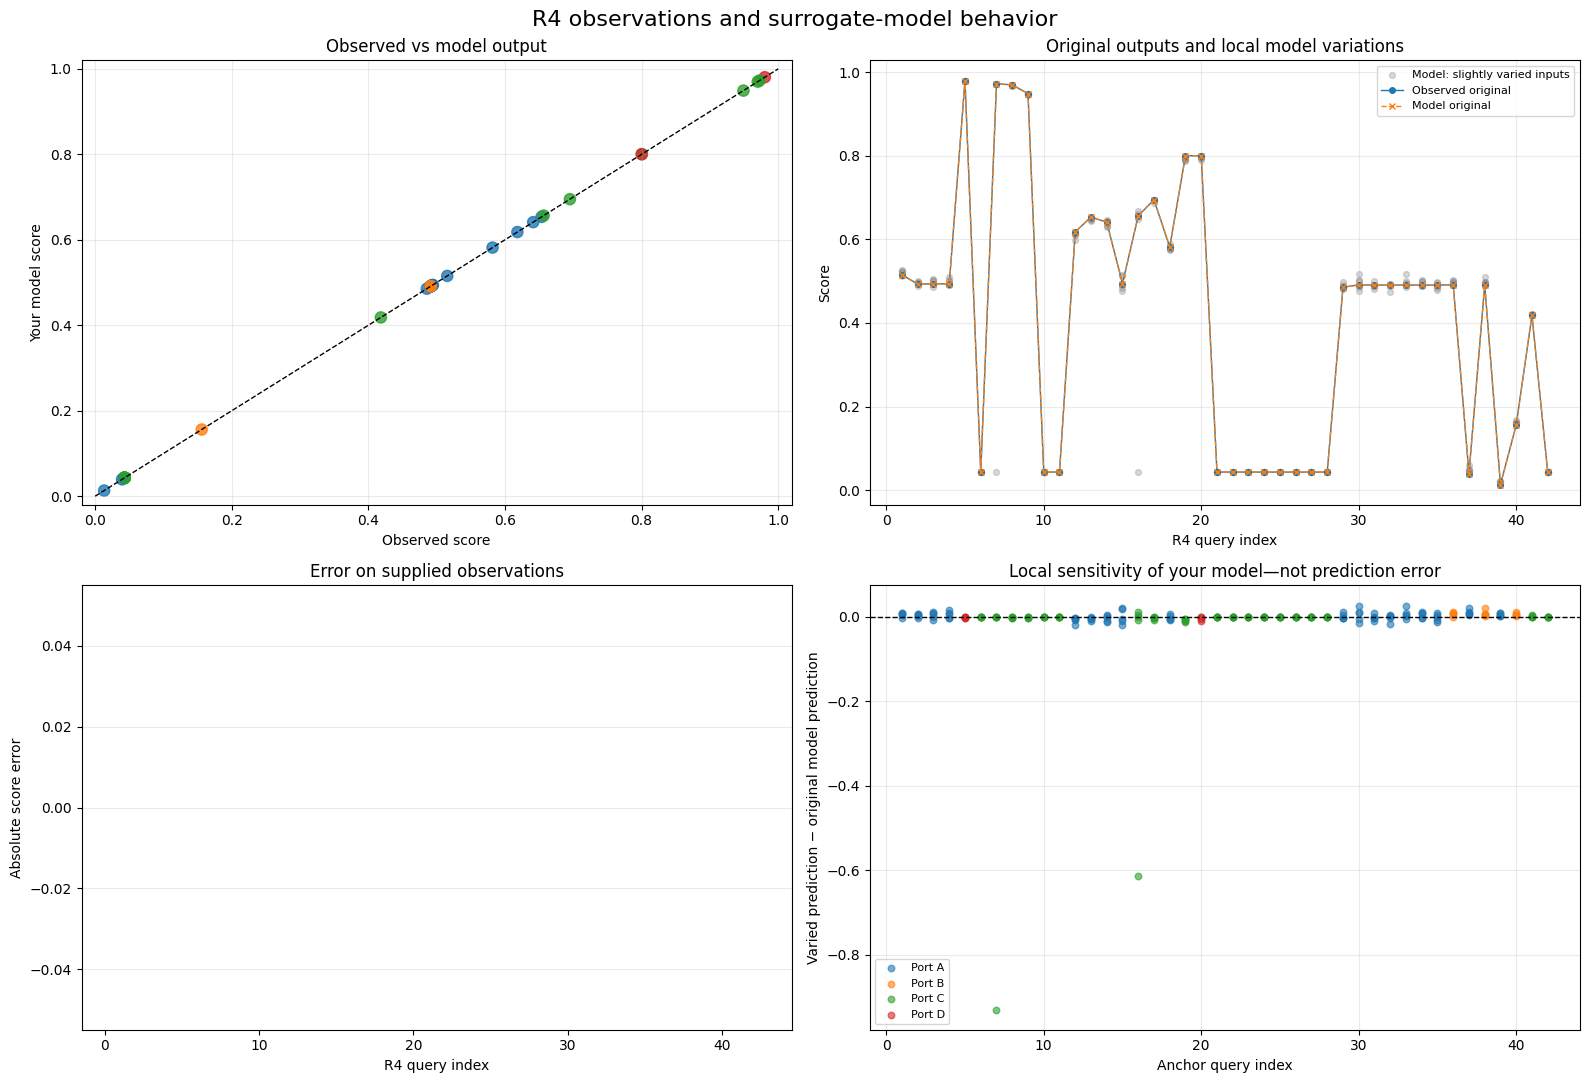

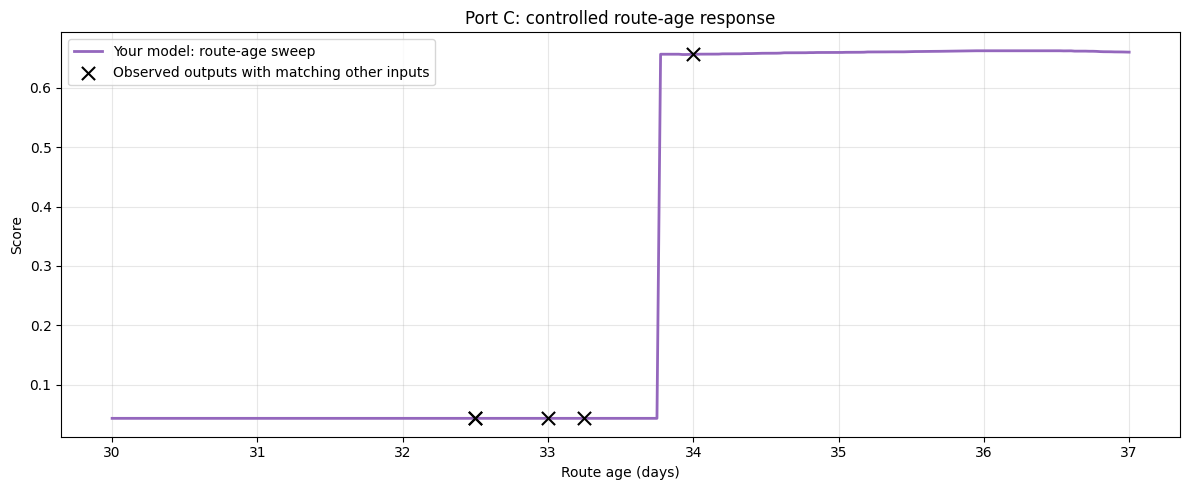

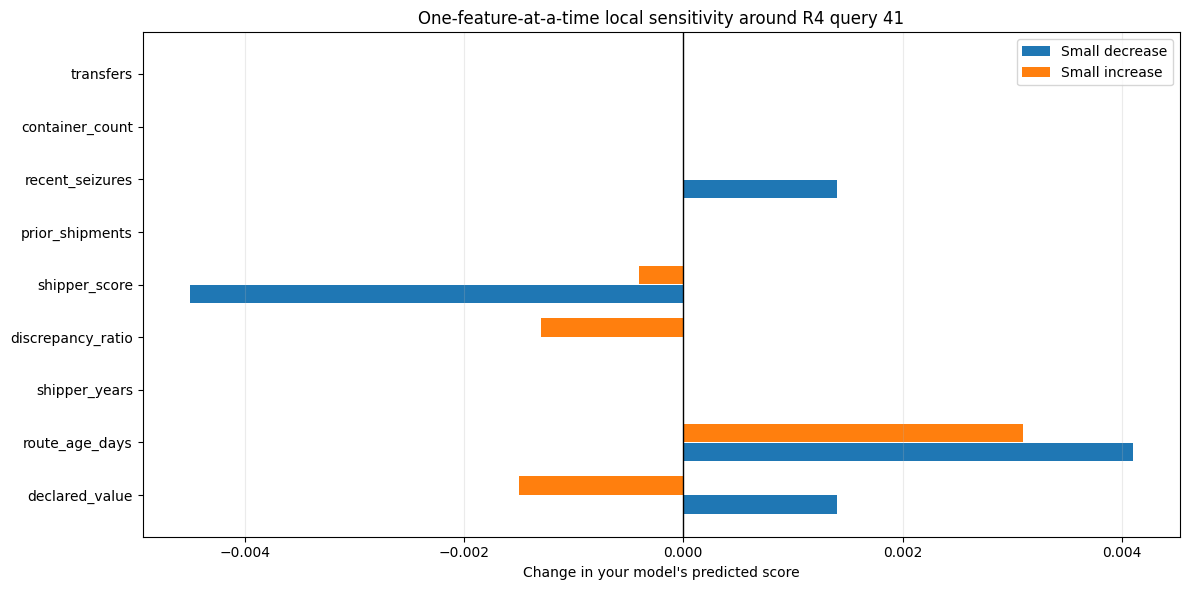


Saved files:
  feature_sensitivity_query_41.csv
  feature_sensitivity_query_41.png
  port_C_route_age_sweep.csv
  port_C_route_age_sweep.png
  r4_local_variations.csv
  r4_local_variations.json
  r4_observed_vs_model.csv
  r4_overview.png

Varied-input outputs are estimated. Do not treat them as verified hidden-system training labels.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ============================================================
# R4 OBSERVATIONS + YOUR MODEL OUTPUTS + LOCAL VARIATIONS
# Run AFTER your training notebook.
# Requires predict_batch_json(...) or final_pipeline.
# ============================================================

import json
import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
VARIATIONS_PER_POINT = 5
PERTURBATION_FRACTION = 0.005  # 0.5% of each allowed feature range
rng = np.random.default_rng(SEED)

OUT = Path("r4_visualizations")
OUT.mkdir(exist_ok=True)

# ============================================================
# 1. YOUR 42 OBSERVATIONS
# Column order:
# query_index, score, decision, container_count, declared_value,
# discrepancy_ratio, port, prior_shipments, recent_seizures,
# route_age_days, shipper_score, shipper_years, transfers
# ============================================================

RAW = """
42 0.0430 DECLINE 50 10 0.5 C 10 2.5 32.5 600 20 3
41 0.4183 DECLINE 86.08 10.577 0.089 C 3.103 4.622 41.561 577.789 0.287 1.295
40 0.1560 DECLINE 50 65 0.65 B 10 1 63 520 15 3
39 0.0132 DECLINE 50 90 0.2 A 10 0.5 70 350 5 3
38 0.4913 APPROVE 50 10 0.5 B 10 2.5 46.5 565 20 3
37 0.0393 DECLINE 50 10 0.2 A 10 0.5 70 350 5 3
36 0.4913 APPROVE 50 10 0.5 B 10 2.5 46.5 565 20 3
35 0.4908 APPROVE 50 10 0.5 A 10 2.5 46.5 564.5 20 3
34 0.4908 APPROVE 50 10 0.5 A 10 2.5 46.5 563.5 20 3
33 0.4908 APPROVE 50 10 0.5 A 10 2.5 46.5 562.5 20 3
32 0.4908 APPROVE 50 10 0.5 A 10 2.5 46.5 564 20 3
31 0.4908 APPROVE 50 10 0.5 A 10 2.5 46.5 563 20 3
30 0.4911 APPROVE 50 10 0.5 A 10 2.5 46.5 562 20 3
29 0.4856 DECLINE 50 10 0.5 A 10 2.5 46.5 561 20 3
28 0.0430 DECLINE 50 9.8 0.97 C 10 4.44 33.5 880 30 3
27 0.0430 DECLINE 50 9.8 0.97 C 10 4.44 33.25 880 30 3
26 0.0430 DECLINE 50 9.8 0.97 C 10 4.44 33 880 30 3
25 0.0430 DECLINE 50 9.8 0.5 C 10 4.44 32.5 880 30 3
24 0.0430 DECLINE 50 10 0.5 C 10 4.44 32.5 880 30 3
23 0.0430 DECLINE 50 10 0.5 C 10 2.5 33.25 600 20 3
22 0.0430 DECLINE 50 10 0.5 C 10 2.5 33 600 20 3
21 0.0430 DECLINE 50 10 0.5 C 10 2.5 32.5 600 20 3
20 0.8002 APPROVE 25 37 0.75 D 17 3.5 40 587 37 5.88
19 0.8005 APPROVE 25 37 0.75 C 17 3.5 40 587 37 5.88
18 0.5818 APPROVE 50 10 0.5 A 10 2.5 46.5 550 25 3
17 0.6951 APPROVE 51 11 0.52 C 11 2.7 36 605 20 3
16 0.6566 APPROVE 50 10 0.5 C 10 2.5 34 600 20 3
15 0.4944 APPROVE 50 10 0.5 A 10 2.5 46.5 575 20 3
14 0.6413 APPROVE 50 10 0.5 A 10 3 46.5 575 20 3
13 0.6536 APPROVE 50 10 0.5 A 10 2.5 46.5 900 20 3
12 0.6182 APPROVE 50 10 0.5 A 10 2.5 46.5 750 20 3
11 0.0430 DECLINE 67 9.8 0.97 C 9.8 4.44 27.5 880 30 4.8
10 0.0430 DECLINE 67 9.8 0.97 C 9.8 2.5 27.5 880 30 4.8
9 0.9492 APPROVE 67 9.8 0.97 C 9.8 4.44 45 880 30 4.8
8 0.9701 APPROVE 67 9.8 0.97 C 9.8 4.44 40 880 30 4.8
7 0.9728 APPROVE 67 9.8 0.97 C 9.8 4.44 34 880 30 4.8
6 0.0430 DECLINE 50 10 0.5 C 10 2.5 27.5 600 20 3
5 0.9805 APPROVE 67 9.8 0.97 D 9.8 4.44 27.5 880 30 4.8
4 0.4937 APPROVE 50 10 0.5 A 10 2.5 46.5 569 20 3
3 0.4938 APPROVE 50 10 0.5 A 10 2.5 46.5 567 20 3
2 0.4929 APPROVE 50 10 0.5 A 10 2.5 46.5 565 20 3
1 0.5155 APPROVE 50 10 0.5 A 10 2.5 46.5 600 20 3
"""

COLUMNS = [
    "query_index", "score", "decision",
    "container_count", "declared_value",
    "discrepancy_ratio", "port",
    "prior_shipments", "recent_seizures",
    "route_age_days", "shipper_score",
    "shipper_years", "transfers",
]

parsed = [
    re.split(r"\s+", line.strip())
    for line in RAW.strip().splitlines()
    if line.strip()
]

if any(len(row) != len(COLUMNS) for row in parsed):
    raise ValueError("An observation has an incorrect number of columns.")

observed = pd.DataFrame(parsed, columns=COLUMNS)

for column in COLUMNS:
    if column not in ["port", "decision"]:
        observed[column] = pd.to_numeric(observed[column])

observed["query_index"] = observed["query_index"].astype(int)
observed = observed.sort_values("query_index").reset_index(drop=True)

BOUNDS = {
    "declared_value": (0.0, 100.0),
    "route_age_days": (18.0, 75.0),
    "shipper_years": (0.0, 40.0),
    "discrepancy_ratio": (0.0, 1.0),
    "shipper_score": (300.0, 900.0),
    "prior_shipments": (0.0, 20.0),
    "recent_seizures": (0.0, 5.0),
    "container_count": (0.0, 100.0),
    "transfers": (0.0, 6.0),
}

INPUT_FIELDS = list(BOUNDS) + ["port"]

# ============================================================
# 2. CONNECT TO YOUR EXISTING PREDICTION API
# Supports your previous response formats:
#
# {"prediction": {"score": ..., "decision": ...}}
# {"score": ..., "decision": ...}
# ============================================================

if callable(globals().get("predict_batch_json")):
    model_predict = globals()["predict_batch_json"]
elif (
    "final_pipeline" in globals()
    and hasattr(final_pipeline, "predict_batch_json")
):
    model_predict = final_pipeline.predict_batch_json
else:
    raise RuntimeError(
        "Run your training code first so predict_batch_json exists."
    )


def predict_frame(frame):
    inputs = frame[INPUT_FIELDS].to_dict("records")
    results = model_predict(inputs)

    if len(results) != len(inputs):
        raise RuntimeError("Prediction count does not match input count.")

    rows = []

    for result in results:
        if not isinstance(result, dict):
            raise ValueError("Model API must return dictionaries.")

        output = result.get("prediction", result)

        if not isinstance(output, dict) or "score" not in output:
            raise ValueError(
                "Expected score/decision fields in each prediction."
            )

        score = float(output["score"])
        if not np.isfinite(score) or not 0 <= score <= 1:
            raise ValueError(f"Invalid predicted score: {score}")

        decision = str(output["decision"]).upper()
        decision = {
            "APPROVED": "APPROVE",
            "DECLINED": "DECLINE",
        }.get(decision, decision)

        if decision not in ["APPROVE", "DECLINE"]:
            raise ValueError(f"Invalid predicted decision: {decision}")

        rows.append({
            "model_score": score,
            "model_decision": decision,
        })

    return pd.DataFrame(rows)


baseline_predictions = predict_frame(observed)

comparison = pd.concat(
    [observed, baseline_predictions], axis=1
)

comparison["residual"] = (
    comparison["score"] - comparison["model_score"]
)
comparison["absolute_error"] = comparison["residual"].abs()
comparison["decision_match"] = (
    comparison["decision"] == comparison["model_decision"]
)

print("\nOBSERVED OUTPUTS VS YOUR MODEL")
print(comparison[[
    "query_index", "score", "model_score",
    "decision", "model_decision", "absolute_error",
]].to_string(index=False))

print("\nDescriptive comparison on supplied points:")
print("MAE:", comparison["absolute_error"].mean())
print("Maximum error:", comparison["absolute_error"].max())
print(
    "Decision agreement:",
    f"{100 * comparison['decision_match'].mean():.2f}%"
)
print(
    "Not an unseen-data accuracy test if these points were used in training."
)

comparison.to_csv(OUT / "r4_observed_vs_model.csv", index=False)

# ============================================================
# 3. GENERATE SLIGHT INPUT VARIATIONS
# Outputs are computed by YOUR MODEL, not by adding score noise.
# Keep port unchanged.
# ============================================================

def input_key(record):
    return json.dumps(
        {field: record[field] for field in INPUT_FIELDS},
        sort_keys=True,
        separators=(",", ":"),
    )


seen = {
    input_key(record)
    for record in observed[INPUT_FIELDS].to_dict("records")
}

variations = []

for _, anchor in comparison.iterrows():
    generated = 0
    attempts = 0

    while generated < VARIATIONS_PER_POINT:
        attempts += 1
        if attempts > 1000:
            raise RuntimeError("Could not generate distinct local inputs.")

        record = {
            field: anchor[field]
            for field in INPUT_FIELDS
        }

        for field, (low, high) in BOUNDS.items():
            sigma = PERTURBATION_FRACTION * (high - low)
            record[field] = round(float(np.clip(
                float(anchor[field]) + rng.normal(0, sigma),
                low,
                high,
            )), 4)

        key = input_key(record)
        if key in seen:
            continue

        seen.add(key)
        generated += 1

        variations.append({
            **record,
            "anchor_query": int(anchor["query_index"]),
            "variation_index": generated,
            "anchor_observed_score": float(anchor["score"]),
            "anchor_model_score": float(anchor["model_score"]),
            "anchor_model_decision": anchor["model_decision"],
        })

varied = pd.DataFrame(variations)
varied_predictions = predict_frame(varied)
varied = pd.concat([varied, varied_predictions], axis=1)

varied["model_score_change"] = (
    varied["model_score"] - varied["anchor_model_score"]
)

varied["model_decision_changed"] = (
    varied["model_decision"] != varied["anchor_model_decision"]
)

varied["label_source"] = "surrogate_estimate"
varied["verified"] = False

varied.to_csv(OUT / "r4_local_variations.csv", index=False)

variation_json = []

for row in varied.to_dict("records"):
    variation_json.append({
        "anchor_query": row["anchor_query"],
        "variation_index": row["variation_index"],
        "input": {
            field: row[field] for field in INPUT_FIELDS
        },
        "estimated_output": {
            "score": row["model_score"],
            "decision": row["model_decision"],
        },
        "verified": False,
        "label_source": "surrogate_estimate",
    })

with open(OUT / "r4_local_variations.json", "w") as f:
    json.dump({
        "count": len(variation_json),
        "warning": "Outputs are model estimates, not observations.",
        "queries": variation_json,
    }, f, indent=2, allow_nan=False)

print(f"\nGenerated {len(varied)} slightly varied inputs.")
print(
    "Model decision changes under perturbation:",
    int(varied["model_decision_changed"].sum()),
)

# ============================================================
# 4. OVERVIEW VISUALIZATION
# ============================================================

plt.style.use("default")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# A. Observed score vs model score
ax = axes[0, 0]
colors = comparison["port"].map({
    "A": "tab:blue",
    "B": "tab:orange",
    "C": "tab:green",
    "D": "tab:red",
})

ax.scatter(
    comparison["score"],
    comparison["model_score"],
    c=colors,
    s=65,
    alpha=0.8,
)
ax.plot([0, 1], [0, 1], "--", color="black", linewidth=1)

for _, row in comparison.iterrows():
    if row["absolute_error"] > 0.02:
        ax.annotate(
            str(int(row["query_index"])),
            (row["score"], row["model_score"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

ax.set(
    xlabel="Observed score",
    ylabel="Your model score",
    title="Observed vs model output",
    xlim=(-0.02, 1.02),
    ylim=(-0.02, 1.02),
)
ax.grid(alpha=0.25)

# B. Scores by query, plus perturbed predictions
ax = axes[0, 1]
ax.scatter(
    varied["anchor_query"],
    varied["model_score"],
    color="gray",
    alpha=0.30,
    s=18,
    label="Model: slightly varied inputs",
)
ax.plot(
    comparison["query_index"],
    comparison["score"],
    "o-",
    markersize=4,
    linewidth=1,
    label="Observed original",
)
ax.plot(
    comparison["query_index"],
    comparison["model_score"],
    "x--",
    markersize=5,
    linewidth=1,
    label="Model original",
)
ax.set(
    xlabel="R4 query index",
    ylabel="Score",
    title="Original outputs and local model variations",
)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# C. Original-point absolute errors
ax = axes[1, 0]
ax.bar(
    comparison["query_index"],
    comparison["absolute_error"],
    color=colors,
)
ax.set(
    xlabel="R4 query index",
    ylabel="Absolute score error",
    title="Error on supplied observations",
)
ax.grid(axis="y", alpha=0.25)

# D. Predicted local score change
ax = axes[1, 1]
for port, color in [
    ("A", "tab:blue"),
    ("B", "tab:orange"),
    ("C", "tab:green"),
    ("D", "tab:red"),
]:
    subset = varied[varied["port"] == port]
    ax.scatter(
        subset["anchor_query"],
        subset["model_score_change"],
        color=color,
        alpha=0.6,
        s=22,
        label=f"Port {port}",
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set(
    xlabel="Anchor query index",
    ylabel="Varied prediction − original model prediction",
    title="Local sensitivity of your model—not prediction error",
)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

fig.suptitle(
    "R4 observations and surrogate-model behavior",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(OUT / "r4_overview.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# 5. CONTROLLED PORT-C ROUTE-AGE SWEEP
# Vary ONLY route_age_days; keep every other field fixed.
# ============================================================

anchor = observed.loc[
    observed["query_index"] == 16,
    INPUT_FIELDS,
].iloc[0].to_dict()

route_ages = np.linspace(30, 37, 281)

sweep_inputs = [
    {**anchor, "route_age_days": float(age)}
    for age in route_ages
]

sweep = pd.DataFrame(sweep_inputs)
sweep_prediction = predict_frame(sweep)
sweep = pd.concat([sweep, sweep_prediction], axis=1)

# Match observed rows to this exact anchor on all OTHER features.
match = np.ones(len(observed), dtype=bool)

for field in INPUT_FIELDS:
    if field == "route_age_days":
        continue
    if field == "port":
        match &= observed[field].eq(anchor[field]).to_numpy()
    else:
        match &= np.isclose(
            observed[field].to_numpy(dtype=float),
            float(anchor[field]),
            atol=1e-10,
            rtol=0,
        )

matching_observations = observed.loc[match]
matching_observations = matching_observations[
    matching_observations["route_age_days"].between(30, 37)
]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    sweep["route_age_days"],
    sweep["model_score"],
    color="tab:purple",
    linewidth=2,
    label="Your model: route-age sweep",
)

ax.scatter(
    matching_observations["route_age_days"],
    matching_observations["score"],
    color="black",
    marker="x",
    s=90,
    label="Observed outputs with matching other inputs",
    zorder=5,
)

ax.set(
    xlabel="Route age (days)",
    ylabel="Score",
    title="Port C: controlled route-age response",
)
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    OUT / "port_C_route_age_sweep.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

sweep["label_source"] = "surrogate_estimate"
sweep["verified"] = False
sweep.to_csv(OUT / "port_C_route_age_sweep.csv", index=False)

# ============================================================
# 6. FEATURE-BY-FEATURE LOCAL SENSITIVITY
# Change one field at a time around R4 query 41.
# ============================================================

sensitivity_anchor = observed.loc[
    observed["query_index"] == 41,
    INPUT_FIELDS,
].iloc[0].to_dict()

anchor_prediction = predict_frame(
    pd.DataFrame([sensitivity_anchor])
).iloc[0]["model_score"]

sensitivity_inputs = []
sensitivity_metadata = []

for field, (low, high) in BOUNDS.items():
    delta = PERTURBATION_FRACTION * (high - low)

    for direction in [-1, 1]:
        record = dict(sensitivity_anchor)
        record[field] = float(np.clip(
            record[field] + direction * delta,
            low,
            high,
        ))

        sensitivity_inputs.append(record)
        sensitivity_metadata.append({
            "feature": field,
            "direction": "decrease" if direction == -1 else "increase",
            "actual_input_change": (
                record[field] - sensitivity_anchor[field]
            ),
        })

sensitivity = pd.DataFrame(sensitivity_metadata)
sensitivity_predictions = predict_frame(
    pd.DataFrame(sensitivity_inputs)
)

sensitivity["model_score"] = sensitivity_predictions["model_score"]
sensitivity["score_change"] = (
    sensitivity["model_score"] - anchor_prediction
)

fig, ax = plt.subplots(figsize=(12, 6))

positions = np.arange(len(BOUNDS))
decreased = sensitivity[
    sensitivity["direction"] == "decrease"
]["score_change"].to_numpy()
increased = sensitivity[
    sensitivity["direction"] == "increase"
]["score_change"].to_numpy()

ax.barh(
    positions - 0.18,
    decreased,
    height=0.35,
    label="Small decrease",
    color="tab:blue",
)
ax.barh(
    positions + 0.18,
    increased,
    height=0.35,
    label="Small increase",
    color="tab:orange",
)

ax.set_yticks(positions)
ax.set_yticklabels(list(BOUNDS))
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Change in your model's predicted score")
ax.set_title(
    "One-feature-at-a-time local sensitivity around R4 query 41"
)
ax.legend()
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
fig.savefig(
    OUT / "feature_sensitivity_query_41.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

sensitivity.to_csv(
    OUT / "feature_sensitivity_query_41.csv",
    index=False,
)

# ============================================================
# 7. DOWNLOAD PLOTS AND DATA
# ============================================================

zip_path = shutil.make_archive(
    "r4_visualizations_bundle",
    "zip",
    root_dir=OUT,
)

print("\nSaved files:")
for path in sorted(OUT.iterdir()):
    print(" ", path.name)

print(
    "\nVaried-input outputs are estimated. "
    "Do not treat them as verified hidden-system training labels."
)

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("ZIP saved locally:", zip_path)

In [4]:
import numpy as np
import pandas as pd

required = ["test_model", "Xd", "yd", "yt", "test_scores"]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the full training notebook first. Missing: "
        + ", ".join(missing)
    )

def calculate_scores(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.clip(
        np.asarray(predicted, dtype=float).reshape(-1), 0, 1
    )

    if len(actual) != len(predicted):
        raise ValueError("Actual and predicted lengths differ.")

    error = np.abs(actual - predicted)

    from sklearn.metrics import r2_score

    return {
        "Samples": len(actual),
        "R²": r2_score(actual, predicted),
        "MAE": error.mean(),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "Median absolute error": np.median(error),
        "95th percentile error": np.quantile(error, 0.95),
        "Maximum error": error.max(),
        "Exact match % (4 decimals)": 100 * np.mean(
            np.round(actual, 4) == np.round(predicted, 4)
        ),
        "Near match % (error ≤ 0.001)": 100 * np.mean(
            error <= 0.001
        ),
    }

# This model was fitted on the development/training partition.
training_predictions = np.clip(
    test_model.predict(Xd), 0, 1
)

# These were saved before the final model trained on all observations.
testing_predictions = np.asarray(test_scores)

summary = pd.DataFrame({
    "Training": calculate_scores(yd, training_predictions),
    "Held-out testing": calculate_scores(yt, testing_predictions),
})

print("\nTRAINING AND TESTING SCORES")
print(summary.round(6).to_string())

# Decision accuracy, if the necessary variables exist.
if all(name in globals() for name in ["ld", "lt"]):
    from sklearn.metrics import accuracy_score

    if "threshold_dev" in globals():
        threshold = threshold_dev
    elif "development_threshold" in globals():
        threshold = development_threshold
    else:
        rejected = np.asarray(yd)[np.asarray(ld) == "DECLINE"]
        approved = np.asarray(yd)[np.asarray(ld) == "APPROVE"]

        if not len(rejected) or not len(approved):
            raise ValueError("Both decision classes are required.")

        if rejected.max() >= approved.min():
            raise ValueError("A single threshold cannot explain labels.")

        threshold = (rejected.max() + approved.min()) / 2

    train_decisions = np.where(
        training_predictions >= threshold, "APPROVE", "DECLINE"
    )
    test_decisions = np.where(
        testing_predictions >= threshold, "APPROVE", "DECLINE"
    )

    print("\nDECISION ACCURACY")
    print(
        f"Training: {100 * accuracy_score(ld, train_decisions):.2f}%"
    )
    print(
        f"Testing:  {100 * accuracy_score(lt, test_decisions):.2f}%"
    )

summary.to_csv("training_testing_scores.csv")
print("\nSaved: training_testing_scores.csv")


TRAINING AND TESTING SCORES
                              Training  Held-out testing
Samples                          286.0         61.000000
R²                                 1.0          0.967413
MAE                                0.0          0.032745
RMSE                               0.0          0.055207
Median absolute error              0.0          0.015929
95th percentile error              0.0          0.113023
Maximum error                      0.0          0.240333
Exact match % (4 decimals)       100.0         11.475410
Near match % (error ≤ 0.001)     100.0         27.868852

DECISION ACCURACY
Training: 100.00%
Testing:  98.36%

Saved: training_testing_scores.csv
